# Inference — normal (single-seed, multi-episode)

Loads ONE trained checkpoint (the **best** model of a chosen seed) and runs several
inference episodes with it.

1. **Averages across episodes** — reward, distance, signed error: both whole-episode
   scalars *and* step-by-step curves with a shaded standard-error band. All saved to pkl.
2. **Representative nutrient plot** — glucose, free fatty acids, small peptides.
3. **Raw bottleneck (`z_phy`) traces** for a few neurons, with food-consumption events marked.
4. **Decoding hunger / fullness from the bottleneck** — each signal fitted as a
   combination of the 16 neuron outputs (linear, optionally degree-2 polynomial).

Everything comes from **one pooled set of rollouts**, so the episode shown in §2 is the
same episode whose neurons appear in §3 and §4.


In [16]:
# ── Imports ───────────────────────────────────────────────────────────────
import os, json, glob, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_squared_error

from envs.env import FoodEnv
from agents.ppo import PPOAgent
from analysis.latent_analysis import capture_phy_bottleneck_shadow_data

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
print('Imports OK')

Imports OK


In [17]:
# ── Config ────────────────────────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════
# CHOOSE HOW MANY INFERENCE EPISODES TO RUN  ->  N_INFERENCE
# ══════════════════════════════════════════════════════════════════════════
N_INFERENCE = 200          # number of inference episodes for this one seed.
                          # NOTE: keep this >= ~15-20. The cross-validated R^2 in
                          # section 4 is grouped BY EPISODE, so with only a handful
                          # of episodes it is extremely noisy (it swung from -2.8 to
                          # +0.29 between 4 and 20 episodes in testing). 20 episodes
                          # also gives a few runs above REWARD_THRESHOLD.

SEED_TO_LOAD  = 0 #64        # which trained seed's checkpoint to load
CKPT_NAME     = 'best'    # 'best' | 'last' | e.g. 'ep2000'
CKPT_META     = f'results/checkpoints_{SEED_TO_LOAD}/ppo_agent_{CKPT_NAME}_meta.json'

DETERMINISTIC = True      # deterministic policy (argmax / mean action)
REWARD_THRESHOLD = 170.0  # representative episode should beat this return

N_NEURONS_TO_PLOT = 3     # how many raw z_phy neurons to show in section 3
NEURONS_OVERRIDE  = None  # e.g. [0, 5, 11] to pick specific neurons, else None
                          # -> auto-selects the most dynamic (highest-variance)

# ── Section 4: decoding signals FROM the bottleneck neurons ───────────────
# Each target is fitted as a combination of ALL z_phy neuron outputs:
#     hunger   = f(z_phy_0 ... z_phy_15)
#     fullness = f(z_phy_0 ... z_phy_15)
DECODE_TARGETS = ['hunger', 'fullness']

# Which fit(s) to run. Start with linear; add 'poly' to also fit a degree-2
# polynomial ridge (squared + pairwise interaction terms of the neurons):
#     FIT_MODES = ['linear']            <- linear only (default)
#     FIT_MODES = ['linear', 'poly']    <- fit both and compare side by side
FIT_MODES   = ['linear', 'poly']
POLY_DEGREE = 2           # only used when 'poly' is in FIT_MODES
RIDGE_ALPHA = 1.0         # ridge strength for the polynomial fit

CV_FOLDS = 5              # episode-grouped K-fold (held-out predictions)

PLOT_DIR = 'results/plots_inference_normal'
os.makedirs(PLOT_DIR, exist_ok=True)

print(f'Checkpoint      : {CKPT_META}')
print(f'Inference runs  : {N_INFERENCE}  (deterministic={DETERMINISTIC})')
print(f'Decode targets  : {DECODE_TARGETS}   fit modes: {FIT_MODES}')

Checkpoint      : results/checkpoints_0/ppo_agent_best_meta.json
Inference runs  : 200  (deterministic=True)
Decode targets  : ['hunger', 'fullness']   fit modes: ['linear', 'poly']


In [18]:
# ── Load the trained model (rebuilds env + agent + weights in one call) ───
agent = PPOAgent.from_checkpoint(CKPT_META, device='cpu')
env   = agent.env

with open(CKPT_META) as f:
    ckpt_meta = json.load(f)

print(f"Loaded seed {ckpt_meta['seed']} | shared={ckpt_meta['shared']} | "
      f"best training return={ckpt_meta['best_return']:.2f} @ ep{ckpt_meta['best_episode']}")
print('Bottlenecks:')
for name, info in agent.list_bottlenecks().items():
    print(f'   {name:14s} dim={info["dim"]}')
print(f'Nutrients      : {env.nutrient_names}')
print(f'Shadow signals : {env.shadow_nutrient_names}')
print(f'Episode length : {env.max_steps} steps '
      f'({env.awake_steps} awake + {env.sleep_steps} asleep per cycle)')

[FoodEnv] Loading  'glucose'  from  'food_dataset/serum_glucose.csv'
           min=70.0758  max=142.5123   foods=19   time_points=500
[FoodEnv] Loading  'peptides'  from  'food_dataset/small_peptides_absorbed.csv'
           min=0.0000  max=0.0018   foods=19   time_points=500
[FoodEnv] Loading  'fatty_acids'  from  'food_dataset/fatty_acids_absorbed.csv'
           min=0.0000  max=0.0007   foods=19   time_points=500
[FoodEnv] Ready — 19 foods | 3 time-series nutrients | 0 cumulative nutrients
[FoodEnv] Loading shadow nutrient 'fullness'  from  'food_dataset/fullness.csv'
[FoodEnv] Loading shadow nutrient 'hunger'  from  'food_dataset/hunger.csv'
[FoodEnv] Loading shadow nutrient 'cck'  from  'food_dataset/cck.csv'
[FoodEnv] Loading shadow nutrient 'ghrelin'  from  'food_dataset/ghrelin.csv'
[FoodEnv] Loading shadow nutrient 'glp_1'  from  'food_dataset/glp_1.csv'
[FoodEnv] Loading shadow nutrient 'pyy'  from  'food_dataset/pyy.csv'
[FoodEnv] Shadow nutrients ready — 6 signal(s): ['ful

## 1. Run the inference episodes & summarise

One pooled capture runs `N_INFERENCE` episodes and records, step-by-step: the phy-branch
bottleneck `z_phy`, the nutrient state, reward, awake/asleep, the action taken, and every
shadow hormone. All later sections read from these same arrays.

- **avg reward** — mean reward *per step*
- **avg distance** — mean L2 distance of the nutrient state to its target centre
  (same definition as the training log)
- **avg signed error** — mean of (state − target band), 0 inside the band;
  negative = below the band, positive = above


In [19]:
# ── Run N inference episodes (single pooled capture) ──────────────────────
z_phy, targets, episode_idx, meta = capture_phy_bottleneck_shadow_data(
    agent, env,
    n_episodes=N_INFERENCE,
    deterministic=DETERMINISTIC,
    network='actor',
    shadow_names=list(env.shadow_nutrient_names),
)

n_nut  = env.num_nutrients
names  = list(env.nutrient_names)
phy    = meta['phy_state'][:, :n_nut]      # (N, n_nut) normalised nutrient levels
rew    = meta['reward']
awake  = meta['is_awake']
act_sum = meta['action_sum']               # amount eaten this step (agent's action)

tgt  = env._norm_targets
low  = env._norm_target_low
high = env._norm_target_high

# Signed error vs the target BAND (0 inside), and L2 distance to target centre
below  = np.minimum(0.0, phy - low[None, :])
above  = np.maximum(0.0, phy - high[None, :])
signed = below + above                      # (N, n_nut)
signed_step = signed.mean(axis=1)           # (N,)
dist_l2     = np.linalg.norm(phy - tgt[None, :], axis=1)

# Actual consumption: the env ignores actions during sleep, so a food is only
# really eaten if the agent acted AND was awake.
ate = (act_sum > 0) & awake

rows = []
for e in range(N_INFERENCE):
    m = episode_idx == e
    row = {
        'episode':        e,
        'steps':          int(m.sum()),
        'total_reward':   float(rew[m].sum()),
        'avg_reward':     float(rew[m].mean()),      # per step
        'avg_distance':   float(dist_l2[m].mean()),
        'avg_signed_err': float(signed_step[m].mean()),
        'food_items':     int(ate[m].sum()),
    }
    for i, nm in enumerate(names):
        row[f'signed_err_{nm}'] = float(signed[m, i].mean())
    rows.append(row)

stats_df = pd.DataFrame(rows)
print(f'z_phy pooled shape : {z_phy.shape}   (steps x neurons)')
print(f'Episodes           : {N_INFERENCE}\n')
display(stats_df.round(4))

print('\n' + '='*64)
print(f'AGGREGATE across {N_INFERENCE} inference episodes (mean +/- std)')
print('='*64)
for col, label in [('avg_reward',     'Average reward   (per step)'),
                   ('avg_distance',   'Average distance (L2 to target)'),
                   ('avg_signed_err', 'Average signed error'),
                   ('food_items',     'Food items eaten (per episode)')]:
    print(f'  {label:34s}: {stats_df[col].mean():+.4f} +/- {stats_df[col].std():.4f}')
print(f'  {"Total episode return":34s}: {stats_df["total_reward"].mean():+.2f} '
      f'+/- {stats_df["total_reward"].std():.2f}')
print('\n  Per-nutrient signed error (mean across episodes):')
for nm in names:
    print(f'     {nm:14s}: {stats_df[f"signed_err_{nm}"].mean():+.4f}')

stats_df.to_pickle(os.path.join(PLOT_DIR, 'inference_episode_stats.pkl'))
print(f'\nSaved {PLOT_DIR}/inference_episode_stats.pkl  (per-episode totals)')

Pooled 200 episodes -> 86400 total steps, dim 16 (network='actor', signature='phy')
z_phy pooled shape : (86400, 16)   (steps x neurons)
Episodes           : 200



,episode,steps,total_reward,avg_reward,avg_distance,avg_signed_err,food_items,signed_err_glucose,signed_err_peptides,signed_err_fatty_acids
0,0,432,183.0746,0.4238,0.1750,-0.0009,13,-0.0006,0.0019,-0.0041
1,1,432,185.5578,0.4295,0.1632,-0.0025,10,-0.0003,0.0048,-0.0118
2,2,432,171.5841,0.3972,0.1938,0.0056,10,0.0015,0.0200,-0.0046
3,3,432,170.5390,0.3948,0.1932,-0.0027,11,0.0003,0.0080,-0.0162
4,4,432,180.8974,0.4187,0.1690,-0.0011,10,-0.0020,0.0048,-0.0061
...,...,...,...,...,...,...,...,...,...,...
195,195,432,169.2253,0.3917,0.2060,-0.0074,10,-0.0005,-0.0080,-0.0138
196,196,432,183.4513,0.4247,0.1633,-0.0047,11,-0.0015,-0.0015,-0.0112
197,197,432,184.8957,0.4280,0.1866,-0.0076,9,-0.0007,-0.0077,-0.0145
198,198,432,179.7958,0.4162,0.1789,-0.0033,11,-0.0003,-0.0039,-0.0056



AGGREGATE across 200 inference episodes (mean +/- std)
  Average reward   (per step)       : +0.4054 +/- 0.0240
  Average distance (L2 to target)   : +0.1897 +/- 0.0238
  Average signed error              : -0.0012 +/- 0.0075
  Food items eaten (per episode)    : +10.6950 +/- 1.2080
  Total episode return              : +175.14 +/- 10.38

  Per-nutrient signed error (mean across episodes):
     glucose       : -0.0003
     peptides      : +0.0037
     fatty_acids   : -0.0071

Saved results/plots_inference_normal/inference_episode_stats.pkl  (per-episode totals)


### 1b. Step-by-step curves across episodes (mean ± standard error)

The same three quantities, but as a function of **time within the episode**, averaged
across all `N_INFERENCE` runs. The shaded band is the **standard error** of the mean
(`std / sqrt(N)`). Sleep windows are shaded navy.


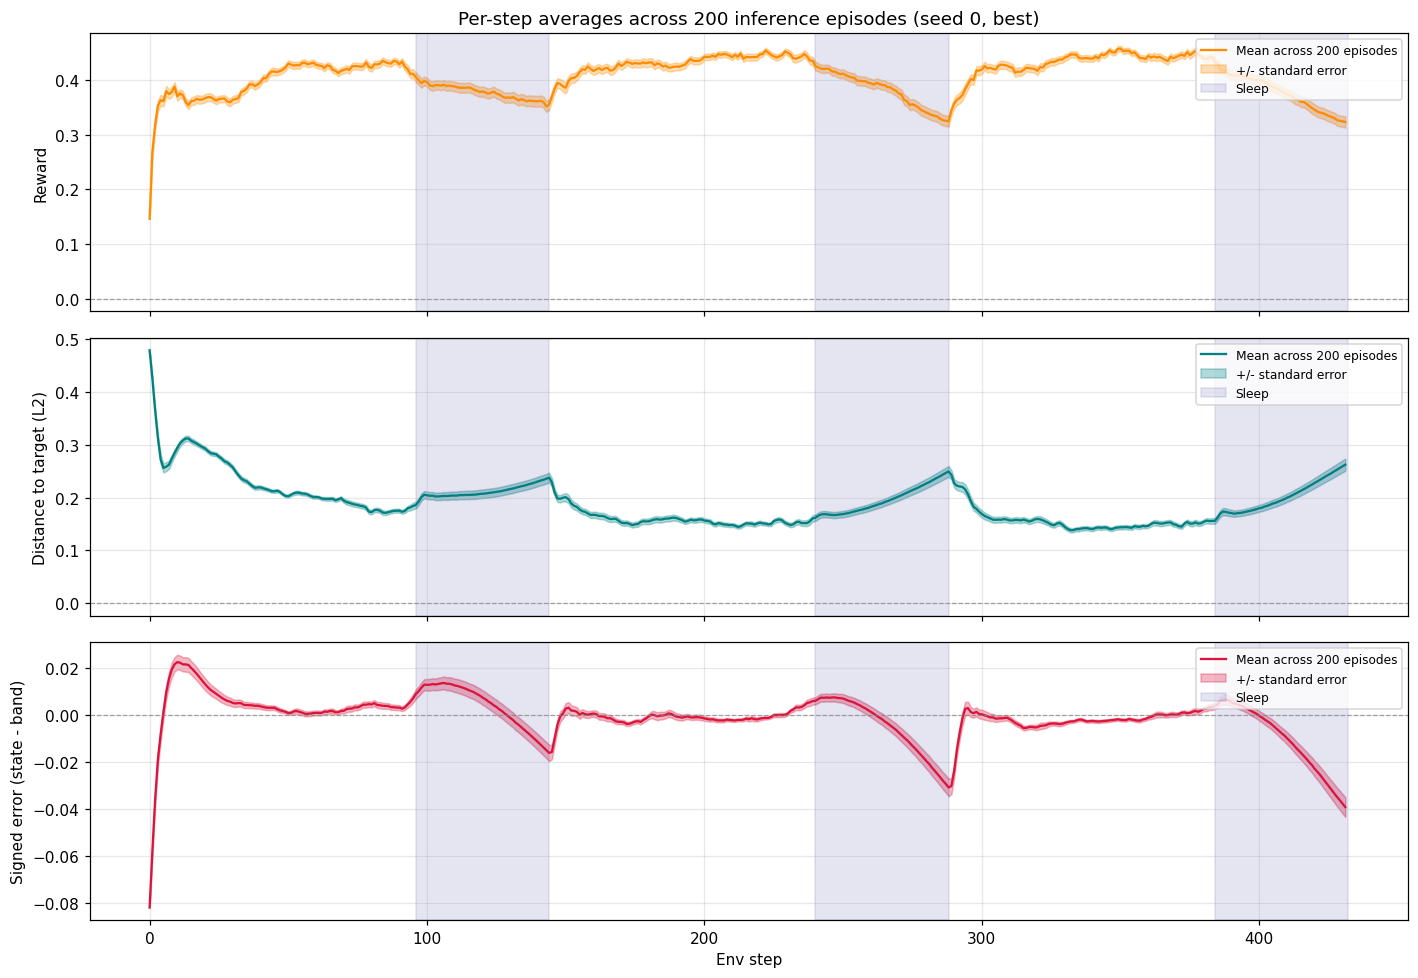

Saved results/plots_inference_normal/perstep_reward_distance_signederror.png
Saved results/plots_inference_normal/inference_perstep_stats.pkl  (432 steps x 20 cols)


In [20]:
# ── Per-step arrays stacked across episodes -> mean +/- SEM ───────────────
ep_lengths = [int((episode_idx == e).sum()) for e in range(N_INFERENCE)]
T_min = min(ep_lengths)
if len(set(ep_lengths)) > 1:
    warnings.warn(f'Episodes differ in length {sorted(set(ep_lengths))}; '
                  f'truncating all to {T_min} steps so they can be stacked.',
                  RuntimeWarning)

def stack_per_step(vec):
    """(N_INFERENCE, T_min) matrix of a per-step quantity."""
    return np.stack([vec[episode_idx == e][:T_min] for e in range(N_INFERENCE)])

R = stack_per_step(rew)          # reward
D = stack_per_step(dist_l2)      # L2 distance
S = stack_per_step(signed_step)  # mean signed error across nutrients

def mean_sem(M):
    mu  = M.mean(axis=0)
    sd  = M.std(axis=0, ddof=1) if M.shape[0] > 1 else np.zeros(M.shape[1])
    sem = sd / np.sqrt(M.shape[0])
    return mu, sd, sem

(r_mu, r_sd, r_sem) = mean_sem(R)
(d_mu, d_sd, d_sem) = mean_sem(D)
(s_mu, s_sd, s_sem) = mean_sem(S)

# Sleep windows (identical every episode — take them from episode 0)
awake_0 = awake[episode_idx == 0][:T_min]

def sleep_windows_from_awake(awake_arr):
    """(start, end) index pairs for each contiguous asleep stretch."""
    wins, in_sleep, start = [], False, 0
    for t, a in enumerate(awake_arr):
        if not a and not in_sleep:
            in_sleep, start = True, t
        elif a and in_sleep:
            in_sleep = False
            wins.append((start, t))
    if in_sleep:
        wins.append((start, len(awake_arr)))
    return wins

def shade_sleep(ax, wins, t_max):
    for k, (ws, we) in enumerate(wins):
        ax.axvspan(ws, min(we, t_max), alpha=0.10, color='navy',
                   label='Sleep' if k == 0 else '')

sleep_wins_all = sleep_windows_from_awake(awake_0)
ts = np.arange(T_min)

# ── Plot ──────────────────────────────────────────────────────────────────
panels = [
    (r_mu, r_sem, 'Reward',                       'darkorange'),
    (d_mu, d_sem, 'Distance to target (L2)',      'teal'),
    (s_mu, s_sem, 'Signed error (state - band)',  'crimson'),
]
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, (mu, sem, label, col) in zip(axes, panels):
    ax.plot(ts, mu, color=col, lw=1.5, label=f'Mean across {N_INFERENCE} episodes')
    ax.fill_between(ts, mu - sem, mu + sem, color=col, alpha=0.30,
                    label='+/- standard error')
    ax.axhline(0, color='grey', lw=0.8, ls='--', alpha=0.7)
    shade_sleep(ax, sleep_wins_all, T_min)
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')

axes[0].set_title(f'Per-step averages across {N_INFERENCE} inference episodes '
                  f'(seed {SEED_TO_LOAD}, {CKPT_NAME})', fontsize=12)
axes[-1].set_xlabel('Env step')
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, 'perstep_reward_distance_signederror.png'),
            bbox_inches='tight')
plt.show()

# ── Save per-step CSV (mean, std AND sem for each metric) ─────────────────
perstep = pd.DataFrame({'step': ts,
                        'reward_mean': r_mu, 'reward_std': r_sd, 'reward_sem': r_sem,
                        'distance_mean': d_mu, 'distance_std': d_sd, 'distance_sem': d_sem,
                        'signed_error_mean': s_mu, 'signed_error_std': s_sd,
                        'signed_error_sem': s_sem,
                        'is_awake': awake_0.astype(int)})
# per-nutrient signed error too
for i, nm in enumerate(names):
    M = stack_per_step(signed[:, i])
    mu, sd, sem = mean_sem(M)
    perstep[f'signed_error_{nm}_mean'] = mu
    perstep[f'signed_error_{nm}_std']  = sd
    perstep[f'signed_error_{nm}_sem']  = sem

perstep.to_pickle(os.path.join(PLOT_DIR, 'inference_perstep_stats.pkl'))
print(f'Saved {PLOT_DIR}/perstep_reward_distance_signederror.png')
print(f'Saved {PLOT_DIR}/inference_perstep_stats.pkl  '
      f'({len(perstep)} steps x {len(perstep.columns)} cols)')

## 2. Representative nutrient plot
### 2a.
Picks the **highest-return episode** and plots the three regulated nutrients in
normalised units (left, target band shaded) and raw physiological units (right).
A warning is printed if the chosen episode's return is below `REWARD_THRESHOLD`.


In [21]:
# ── Pick the representative (best) episode ────────────────────────────────
best_row = stats_df.loc[stats_df['total_reward'].idxmax()]
BEST_EP  = int(best_row['episode'])
best_ret = float(best_row['total_reward'])

print(f'Representative episode: {BEST_EP}  (total return = {best_ret:.2f})')
n_above = int((stats_df['total_reward'] > REWARD_THRESHOLD).sum())
print(f'  {n_above}/{N_INFERENCE} episodes exceeded the {REWARD_THRESHOLD:.0f} threshold.')
if best_ret <= REWARD_THRESHOLD:
    warnings.warn(
        f'Best episode return {best_ret:.2f} is BELOW the {REWARD_THRESHOLD:.0f} '
        'threshold. Plotting it anyway — consider raising N_INFERENCE, or loading a '
        'different seed/checkpoint.', RuntimeWarning)

mask_best = episode_idx == BEST_EP
phy_b   = phy[mask_best]
awake_b = awake[mask_best]
ate_b   = ate[mask_best]
T_b     = phy_b.shape[0]
sleep_wins = sleep_windows_from_awake(awake_b)
t = np.arange(T_b)
print(f'  steps={T_b}, sleep windows={len(sleep_wins)}, food items eaten={ate_b.sum()}')

Representative episode: 189  (total return = 199.66)
  145/200 episodes exceeded the 170 threshold.
  steps=432, sleep windows=3, food items eaten=10


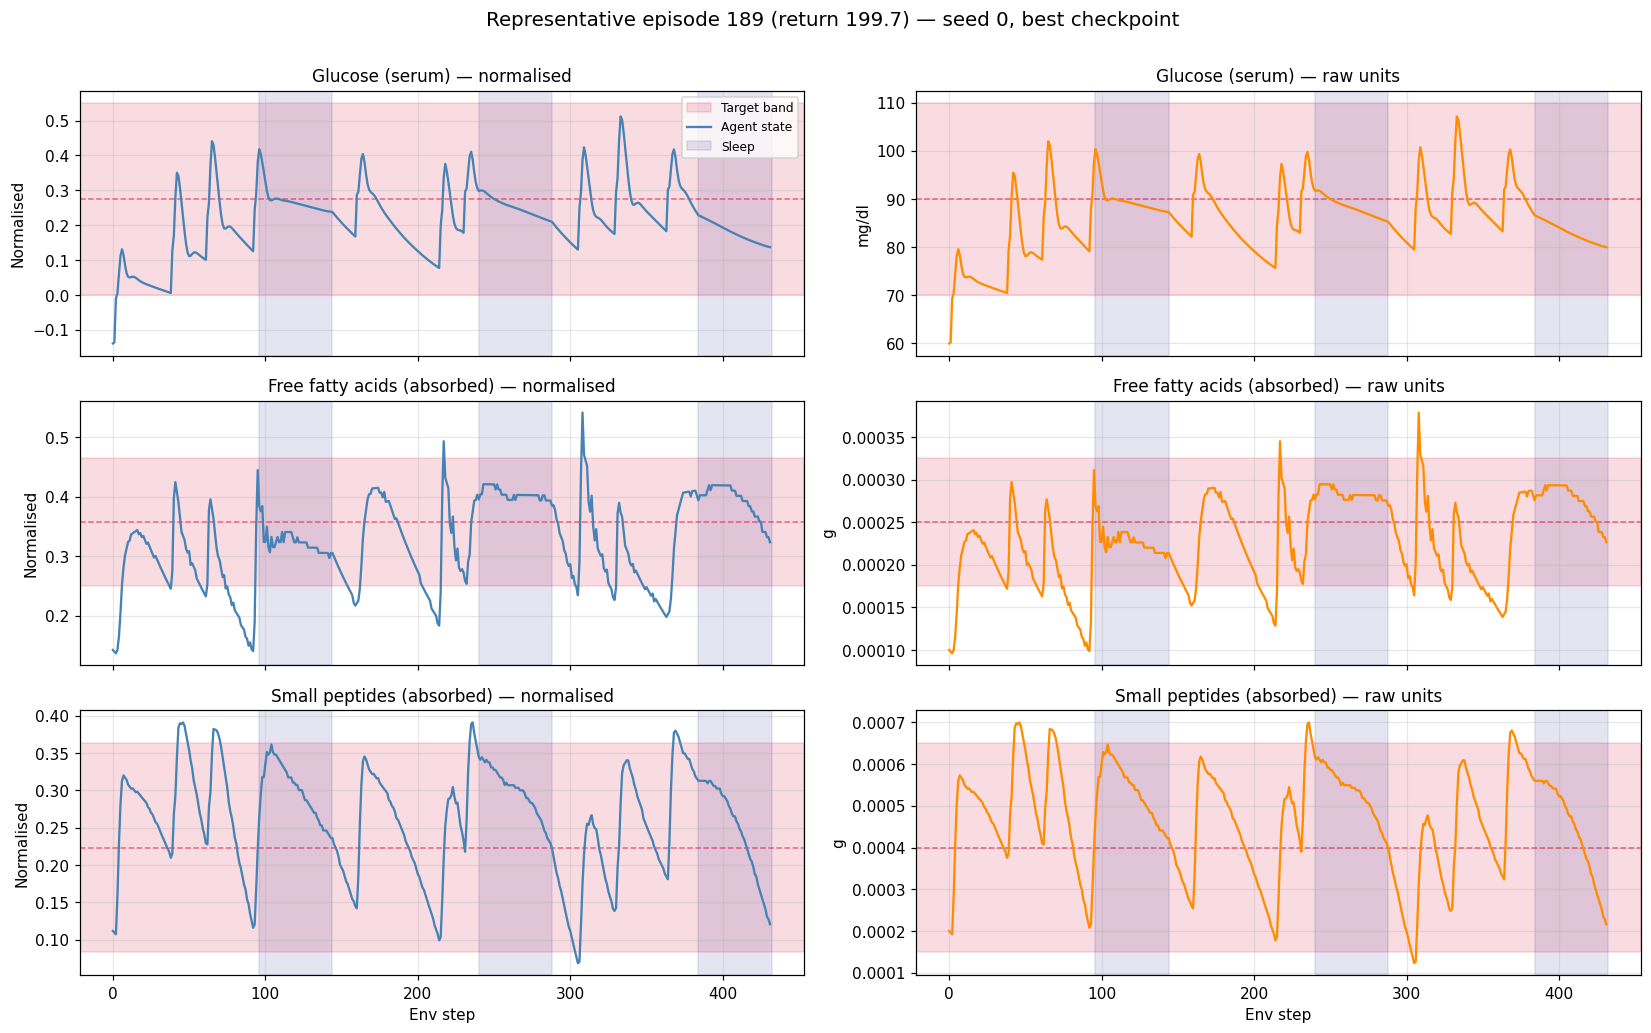

Saved results/plots_inference_normal/nutrients_ep189.png


In [22]:
# ── Figure: glucose / free fatty acids / small peptides ───────────────────
DISPLAY = {
    'glucose':     ('Glucose (serum)',             'mg/dl'),
    'fatty_acids': ('Free fatty acids (absorbed)', 'g'),
    'peptides':    ('Small peptides (absorbed)',   'g'),
}
PLOT_ORDER = [n for n in ['glucose', 'fatty_acids', 'peptides'] if n in names]

fig, axes = plt.subplots(len(PLOT_ORDER), 2, figsize=(15, 3.1 * len(PLOT_ORDER)),
                         sharex=True)
if len(PLOT_ORDER) == 1:
    axes = axes[None, :]

for r, nm in enumerate(PLOT_ORDER):
    i = names.index(nm)
    label, unit = DISPLAY[nm]
    v_min, v_max = env._nutrient_mins[nm], env._nutrient_maxs[nm]
    rng = v_max - v_min

    ax = axes[r, 0]
    ax.axhspan(low[i], high[i], alpha=0.15, color='crimson', label='Target band')
    ax.axhline(tgt[i], ls='--', color='crimson', lw=1.0, alpha=0.6)
    ax.plot(t, phy_b[:, i], color='steelblue', lw=1.5, label='Agent state')
    shade_sleep(ax, sleep_wins, T_b)
    ax.set_ylabel('Normalised')
    ax.set_title(f'{label} — normalised', fontsize=11)
    ax.grid(alpha=0.3)
    if r == 0:
        ax.legend(fontsize=8, loc='upper right')

    ax = axes[r, 1]
    ax.axhspan(low[i]*rng + v_min, high[i]*rng + v_min, alpha=0.15, color='crimson')
    ax.axhline(tgt[i]*rng + v_min, ls='--', color='crimson', lw=1.0, alpha=0.6)
    ax.plot(t, phy_b[:, i]*rng + v_min, color='darkorange', lw=1.5)
    shade_sleep(ax, sleep_wins, T_b)
    ax.set_ylabel(unit)
    ax.set_title(f'{label} — raw units', fontsize=11)
    ax.grid(alpha=0.3)

axes[-1, 0].set_xlabel('Env step')
axes[-1, 1].set_xlabel('Env step')
fig.suptitle(f'Representative episode {BEST_EP} (return {best_ret:.1f}) — '
             f'seed {SEED_TO_LOAD}, {CKPT_NAME} checkpoint', fontsize=13, y=1.005)
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, f'nutrients_ep{BEST_EP}.png'), bbox_inches='tight')
plt.show()
print(f'Saved {PLOT_DIR}/nutrients_ep{BEST_EP}.png')

## 2b. Total calories consumed per day

Per-day energy intake, where a **day** is one full wake+sleep cycle
(`env.cycle_length` steps). Aggregated as mean ± SEM across the `N_INFERENCE`
inference episodes. Sits before the latent/bottleneck analysis below.


Total calories consumed per day  (env day = 144 steps = one wake+sleep cycle)
200 episodes, seed 0

 day  n_episodes  mean_kcal  sem_kcal  min_kcal  max_kcal
   1         200     1564.9      19.9     927.5    2433.3
   2         200     1388.0      25.1     624.0    2330.3
   3         200     1427.5      26.5     624.0    2591.0

Mean daily intake (avg over days)   : 1460.1 kcal
Mean episode total (sum over days)  : 4380.4 kcal


,day,n_episodes,mean_kcal,sem_kcal,min_kcal,max_kcal
0,1,200,1564.94,19.93,927.48,2433.28
1,2,200,1387.98,25.07,624.05,2330.29
2,3,200,1427.53,26.47,624.04,2590.98


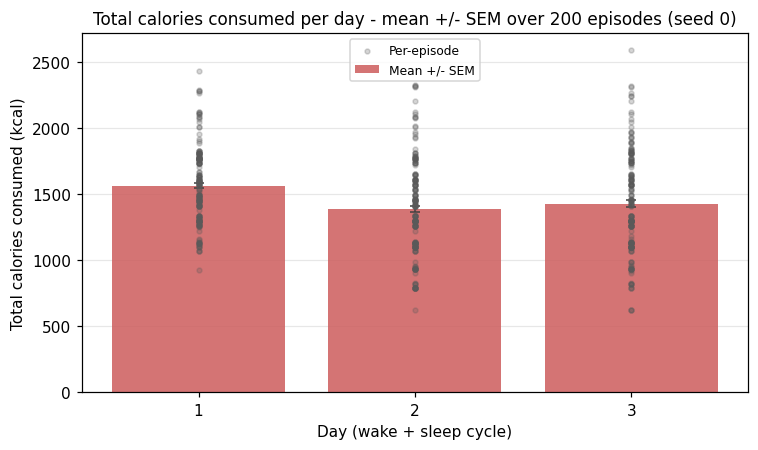

Saved results/plots_inference_normal/calories_per_day.png (+ .pkl)
Saved results/plots_inference_normal/calories_per_episode.pkl  (per-episode per-day kcal, shape (200, 3))


In [24]:
# ── Total calories consumed per day (env "day" = one wake+sleep cycle) ─────
# meta['calories_cumulative'] is cumulative kcal WITHIN each episode (it resets
# to ~0 at every episode start). A "day" is one full sleep/wake cycle of
# env.cycle_length steps, so per-day intake = calories accumulated between
# consecutive day boundaries, aggregated as mean +/- SEM across episodes.
cyc     = env.cycle_length
cal_cum = meta['calories_cumulative']

# per-episode -> vector of kcal eaten in each day of that episode
per_ep_days = []
for e in range(N_INFERENCE):
    ce = cal_cum[episode_idx == e]
    if len(ce) == 0:
        per_ep_days.append(np.array([]))
        continue
    inc = np.diff(ce, prepend=0.0)          # cumulative -> per-step kcal eaten
    inc = np.clip(inc, 0.0, None)           # guard against float noise at resets
    day = np.arange(len(ce)) // cyc         # day index for each step in the episode
    n_days_e = int(day.max()) + 1
    per_ep_days.append(np.array([inc[day == d].sum() for d in range(n_days_e)]))

D = max((len(v) for v in per_ep_days), default=0)
# pad ragged episodes with NaN so a partial final day doesn't bias the mean
mat = np.full((N_INFERENCE, D), np.nan)
for e, v in enumerate(per_ep_days):
    mat[e, :len(v)] = v

counts   = np.sum(~np.isnan(mat), axis=0).astype(int)
day_mean = np.nanmean(mat, axis=0)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')         # ddof=1 on a single episode -> NaN std
    day_std = np.nanstd(mat, axis=0, ddof=1)
day_sem  = np.where(counts > 1, day_std / np.sqrt(np.maximum(counts, 1)), 0.0)

cal_by_day = pd.DataFrame({
    'day':        np.arange(1, D + 1),
    'n_episodes': counts,
    'mean_kcal':  day_mean,
    'sem_kcal':   day_sem,
    'min_kcal':   np.nanmin(mat, axis=0),
    'max_kcal':   np.nanmax(mat, axis=0),
})

# ── print ─────────────────────────────────────────────────────────────────
print(f'Total calories consumed per day  '
      f'(env day = {cyc} steps = one wake+sleep cycle)')
print(f'{N_INFERENCE} episodes, seed {SEED_TO_LOAD}\n')
print(cal_by_day.round(1).to_string(index=False))
ep_totals = [float(v.sum()) for v in per_ep_days if len(v)]
print(f'\nMean daily intake (avg over days)   : {np.nanmean(day_mean):.1f} kcal')
print(f'Mean episode total (sum over days)  : {np.mean(ep_totals):.1f} kcal')
try:
    display(cal_by_day.round(2))
except NameError:
    pass

# ── plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(7, 1.1 * D), 4.2))
x = cal_by_day['day'].values
ax.bar(x, day_mean, yerr=day_sem, capsize=3, color='indianred', alpha=0.85,
       error_kw=dict(lw=1.0, ecolor='0.25'), label='Mean +/- SEM')
for e in range(N_INFERENCE):                # faint per-episode points
    ax.scatter(x, mat[e], s=10, color='0.35', alpha=0.25, zorder=3,
               label='Per-episode' if e == 0 else None)
ax.set_xticks(x)
ax.set_xlabel('Day (wake + sleep cycle)')
ax.set_ylabel('Total calories consumed (kcal)')
ax.set_title(f'Total calories consumed per day - mean +/- SEM over '
             f'{N_INFERENCE} episodes (seed {SEED_TO_LOAD})', fontsize=11)
ax.grid(alpha=0.3, axis='y'); ax.set_axisbelow(True)
ax.legend(fontsize=8, loc='best')
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, 'calories_per_day.png'), bbox_inches='tight')
plt.show()

cal_by_day.to_pickle(os.path.join(PLOT_DIR, 'calories_per_day.pkl'))
print(f'Saved {PLOT_DIR}/calories_per_day.png (+ .pkl)')

# per-episode x per-day matrix (rows = inference episodes, cols = days) — for scatter
cal_per_ep = pd.DataFrame(mat, columns=[f'day{d}' for d in range(1, D + 1)])
cal_per_ep.to_pickle(os.path.join(PLOT_DIR, 'calories_per_episode.pkl'))
print(f'Saved {PLOT_DIR}/calories_per_episode.pkl  (per-episode per-day kcal, shape {mat.shape})')


## 3. Raw bottleneck (`z_phy`) representation

Raw activations of a few bottleneck neurons over the representative episode (no PCA).
**Red dots mark steps where the agent actually ate** — i.e. it chose a food *and* was
awake (the env discards actions during sleep), so you can see how each neuron responds
to feeding events.


z_phy has 16 neurons; plotting [13, 0, 12] (highest variance)
Food consumed on 10/432 steps of episode 189


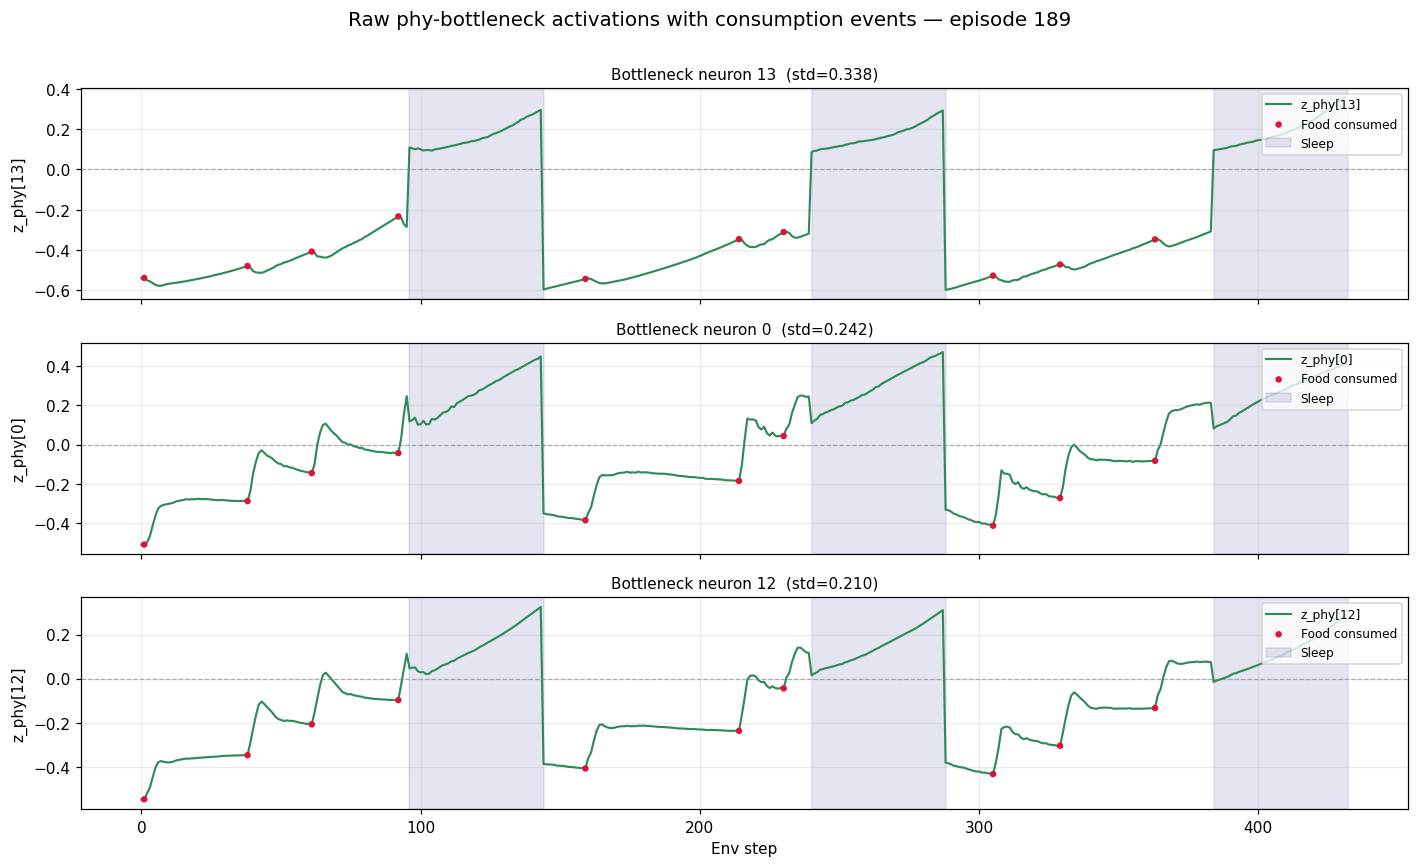

Saved results/plots_inference_normal/z_phy_raw_ep189.png


In [9]:
# ── Raw z_phy neuron traces, with consumption events marked ───────────────
z_dim = z_phy.shape[1]
z_b   = z_phy[mask_best]                     # (T_b, z_dim) this episode only

if NEURONS_OVERRIDE is not None:
    sel = list(NEURONS_OVERRIDE)
else:
    sel = list(np.argsort(z_phy.std(axis=0))[::-1][:N_NEURONS_TO_PLOT])
sel = [int(j) for j in sel]
print(f'z_phy has {z_dim} neurons; plotting {sel} '
      f'({"manual" if NEURONS_OVERRIDE is not None else "highest variance"})')

eat_steps = np.where(ate_b)[0]
print(f'Food consumed on {len(eat_steps)}/{T_b} steps of episode {BEST_EP}')

fig, axes = plt.subplots(len(sel), 1, figsize=(13, 2.6 * len(sel)), sharex=True)
if len(sel) == 1:
    axes = [axes]

for ax, j in zip(axes, sel):
    ax.plot(t, z_b[:, j], color='seagreen', lw=1.4, label=f'z_phy[{j}]')
    ax.scatter(eat_steps, z_b[eat_steps, j], s=18, color='crimson', zorder=5,
               label='Food consumed', edgecolors='none')
    ax.axhline(0, color='grey', lw=0.8, ls='--', alpha=0.6)
    shade_sleep(ax, sleep_wins, T_b)
    ax.set_ylabel(f'z_phy[{j}]')
    ax.set_title(f'Bottleneck neuron {j}  (std={z_phy[:, j].std():.3f})', fontsize=10)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('Env step')
fig.suptitle(f'Raw phy-bottleneck activations with consumption events — '
             f'episode {BEST_EP}', fontsize=13, y=1.005)
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, f'z_phy_raw_ep{BEST_EP}.png'), bbox_inches='tight')
plt.show()
print(f'Saved {PLOT_DIR}/z_phy_raw_ep{BEST_EP}.png')

## 4. Decoding hunger / fullness from the bottleneck

Direction: **signal = f(neurons)**. Each target is fitted from a combination of all 16
bottleneck outputs, one independent fit per target:

- `hunger   = w·z_phy + b`
- `fullness = w·z_phy + b`

`FIT_MODES` (config cell) selects `'linear'` (ordinary least squares) and/or `'poly'`
(degree-2 polynomial ridge — adds squared and pairwise-interaction terms).

All reported scores use **held-out predictions**: a GroupKFold splits by *episode*, so
every point is predicted by a model that never saw its episode. That prevents
within-episode autocorrelation from inflating the fit.


In [10]:
# ── Fit each target from the neuron population ────────────────────────────
def build_model(mode):
    if mode == 'linear':
        return LinearRegression()
    if mode == 'poly':
        return make_pipeline(StandardScaler(),
                             PolynomialFeatures(POLY_DEGREE, include_bias=False),
                             Ridge(alpha=RIDGE_ALPHA))
    raise ValueError(f"unknown fit mode {mode!r} (use 'linear' or 'poly')")


def fit_decoder(X, y, groups, mode):
    """Fit `mode` model, return in-sample + held-out (out-of-fold) metrics."""
    model = build_model(mode).fit(X, y)
    pred_in = model.predict(X)

    n_groups = len(np.unique(groups))
    k = int(min(CV_FOLDS, n_groups))
    oof = np.full_like(y, np.nan, dtype=float)
    if k >= 2:
        for tr, te in GroupKFold(n_splits=k).split(X, y, groups):
            oof[te] = build_model(mode).fit(X[tr], y[tr]).predict(X[te])
    ok = ~np.isnan(oof)

    return {
        'model':   model,
        'pred_in': pred_in,
        'oof':     oof,
        'r2_in':   r2_score(y, pred_in),
        'mse_in':  mean_squared_error(y, pred_in),
        'r2_cv':   r2_score(y[ok], oof[ok])            if ok.any() else np.nan,
        'mse_cv':  mean_squared_error(y[ok], oof[ok])  if ok.any() else np.nan,
        'r_cv':    float(np.corrcoef(y[ok], oof[ok])[0, 1]) if ok.any() else np.nan,
    }


X = z_phy                                   # (N, 16) neuron population
fits, rows4 = {}, []
for tname in DECODE_TARGETS:
    y = np.asarray(targets[tname], dtype=float)
    for mode in FIT_MODES:
        f = fit_decoder(X, y, episode_idx, mode)
        fits[(tname, mode)] = f
        rows4.append({'target': tname, 'fit': mode,
                      'r2_in': f['r2_in'], 'mse_in': f['mse_in'],
                      'r2_cv': f['r2_cv'], 'mse_cv': f['mse_cv'], 'r_cv': f['r_cv']})

decode_df = pd.DataFrame(rows4)
print('Decoding signal FROM the 16 bottleneck neurons '
      '(held-out = episode-grouped K-fold):\n')
display(decode_df.round(4))

print('\n' + '='*70)
for (tname, mode), f in fits.items():
    print(f'{tname.upper():9s} [{mode:6s}]  held-out R^2={f["r2_cv"]:+.4f}  '
          f'MSE={f["mse_cv"]:.6f}  r={f["r_cv"]:+.4f}   '
          f'(in-sample R^2={f["r2_in"]:.4f}, MSE={f["mse_in"]:.6f})')
print('='*70)

decode_df.to_pickle(os.path.join(PLOT_DIR, 'decode_scores.pkl'))
print(f'Saved {PLOT_DIR}/decode_scores.pkl')

/opt/homebrew/anaconda3/envs/workbench/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=1.7198e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/homebrew/anaconda3/envs/workbench/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.35552e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/homebrew/anaconda3/envs/workbench/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.10643e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/homebrew/anaconda3/envs/workbench/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.54582e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos

Decoding signal FROM the 16 bottleneck neurons (held-out = episode-grouped K-fold):



/opt/homebrew/anaconda3/envs/workbench/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.0354e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/homebrew/anaconda3/envs/workbench/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.28978e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


,target,fit,r2_in,mse_in,r2_cv,mse_cv,r_cv
0,hunger,linear,0.4325,0.0131,0.4285,0.0132,0.6546
1,hunger,poly,0.5889,0.0095,0.5785,0.0098,0.7606
2,fullness,linear,0.5599,0.0101,0.5691,0.0099,0.7544
3,fullness,poly,0.6692,0.0076,0.6586,0.0078,0.8116



HUNGER    [linear]  held-out R^2=+0.4285  MSE=0.013228  r=+0.6546   (in-sample R^2=0.4325, MSE=0.013135)
HUNGER    [poly  ]  held-out R^2=+0.5785  MSE=0.009757  r=+0.7606   (in-sample R^2=0.5889, MSE=0.009516)
FULLNESS  [linear]  held-out R^2=+0.5691  MSE=0.009864  r=+0.7544   (in-sample R^2=0.5599, MSE=0.010074)
FULLNESS  [poly  ]  held-out R^2=+0.6586  MSE=0.007814  r=+0.8116   (in-sample R^2=0.6692, MSE=0.007571)
Saved results/plots_inference_normal/decode_scores.pkl


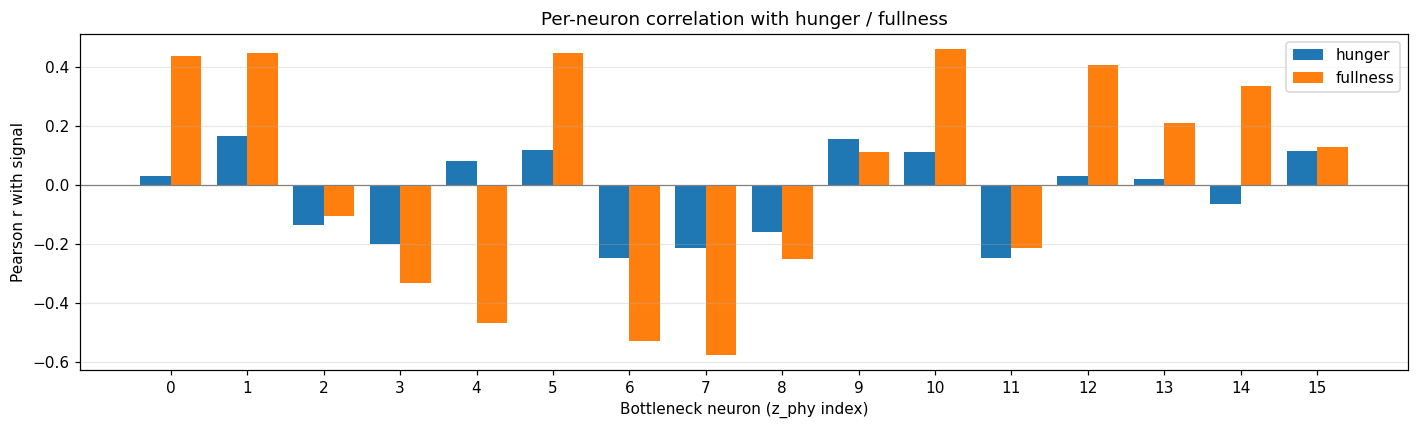

hunger    top-5 single neurons by |r|: z6(-0.249), z11(-0.248), z7(-0.215), z3(-0.200), z1(+0.165)
fullness  top-5 single neurons by |r|: z7(-0.576), z6(-0.530), z4(-0.467), z10(+0.459), z1(+0.446)

Saved results/plots_inference_normal/per_neuron_correlation.png (+ .pkl)


In [11]:
# ── Per-neuron correlation with each target ───────────────────────────────
corr = np.zeros((len(DECODE_TARGETS), z_dim))
for a, tname in enumerate(DECODE_TARGETS):
    y = np.asarray(targets[tname], dtype=float)
    for j in range(z_dim):
        corr[a, j] = np.corrcoef(z_phy[:, j], y)[0, 1]

corr_df = pd.DataFrame(corr.T, columns=[f'r_{t}' for t in DECODE_TARGETS])
corr_df.index.name = 'neuron'

x = np.arange(z_dim); w = 0.8 / len(DECODE_TARGETS)
fig, ax = plt.subplots(figsize=(13, 4))
for a, tname in enumerate(DECODE_TARGETS):
    ax.bar(x + (a - (len(DECODE_TARGETS)-1)/2) * w, corr[a], w, label=tname)
ax.axhline(0, color='grey', lw=0.8)
ax.set_xticks(x)
ax.set_xlabel('Bottleneck neuron (z_phy index)')
ax.set_ylabel('Pearson r with signal')
ax.set_title('Per-neuron correlation with hunger / fullness')
ax.legend(); ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, 'per_neuron_correlation.png'), bbox_inches='tight')
plt.show()

for a, tname in enumerate(DECODE_TARGETS):
    order = np.argsort(np.abs(corr[a]))[::-1][:5]
    print(f'{tname:9s} top-5 single neurons by |r|: '
          + ', '.join(f'z{j}({corr[a, j]:+.3f})' for j in order))

corr_df.to_pickle(os.path.join(PLOT_DIR, 'per_neuron_correlation.pkl'))
print(f'\nSaved {PLOT_DIR}/per_neuron_correlation.png (+ .pkl)')

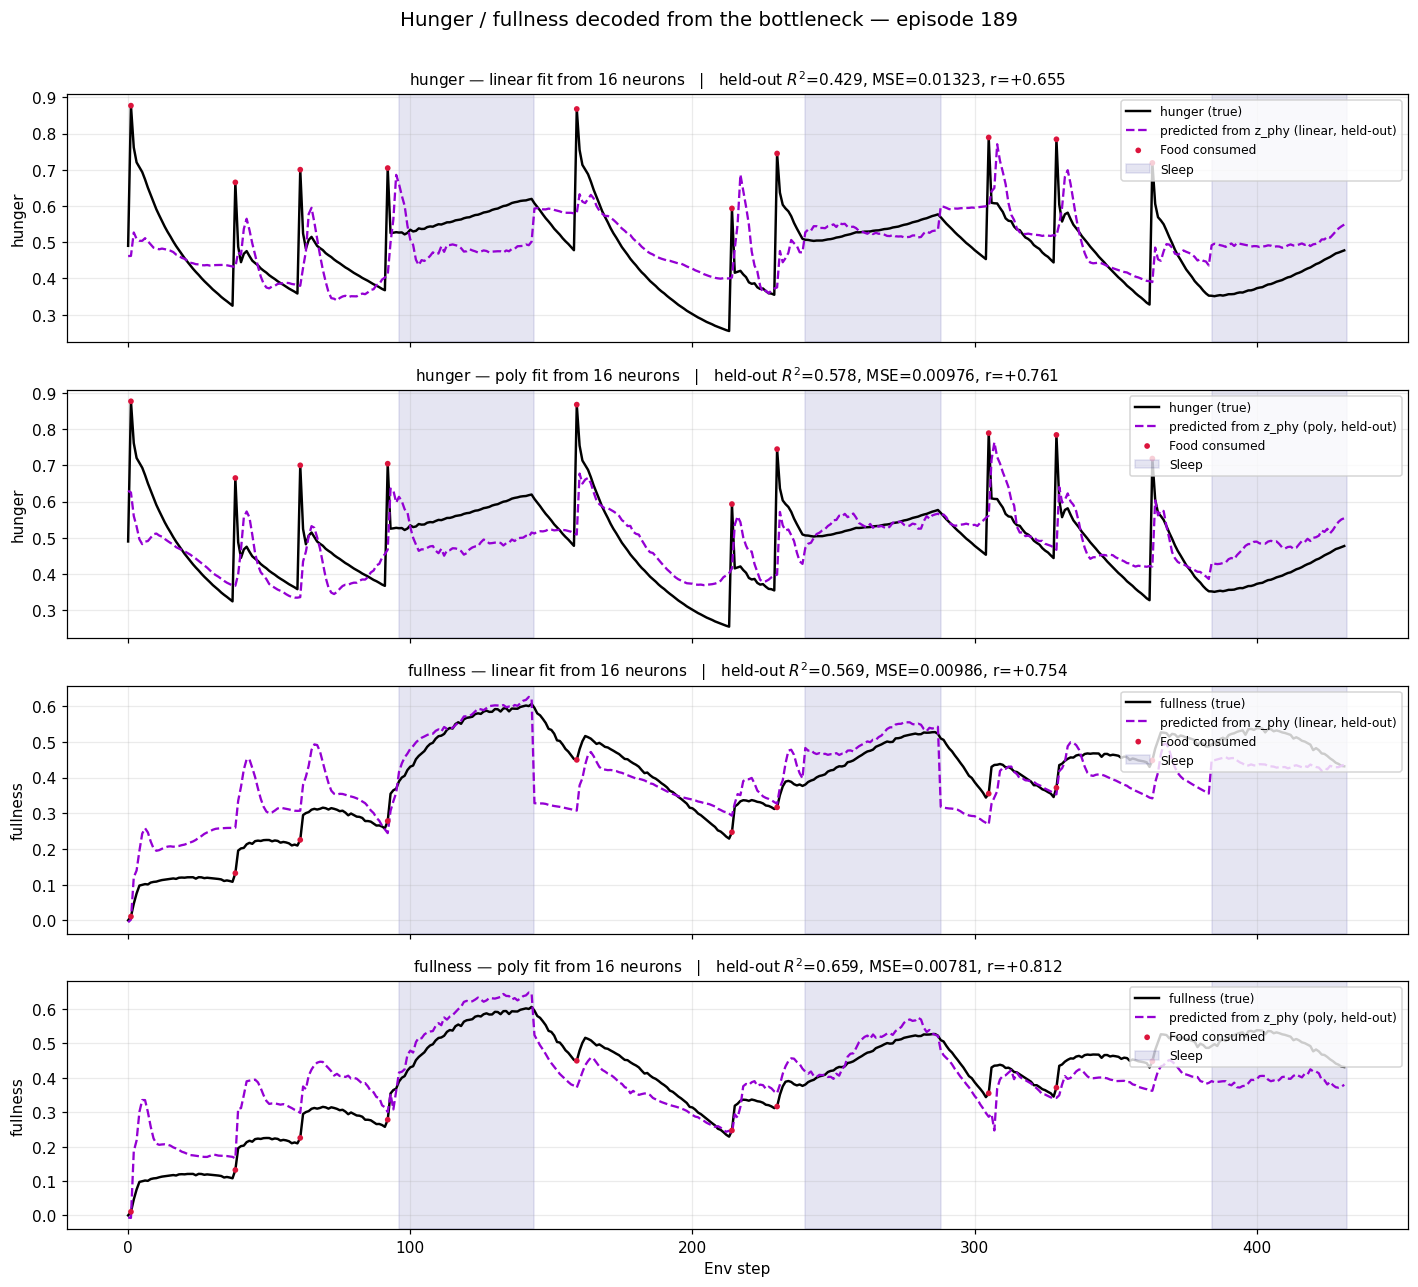

Saved results/plots_inference_normal/decode_timeseries_ep189.png


In [12]:
# ── Time series: true signal vs held-out prediction (representative episode) ──
n_rows = len(DECODE_TARGETS) * len(FIT_MODES)
fig, axes = plt.subplots(n_rows, 1, figsize=(13, 2.9 * n_rows), sharex=True)
if n_rows == 1:
    axes = [axes]

row = 0
for tname in DECODE_TARGETS:
    y = np.asarray(targets[tname], dtype=float)
    for mode in FIT_MODES:
        f  = fits[(tname, mode)]
        ax = axes[row]; row += 1
        ax.plot(t, y[mask_best], color='black', lw=1.6, label=f'{tname} (true)')
        ax.plot(t, f['oof'][mask_best], color='darkviolet', lw=1.5, ls='--',
                label=f'predicted from z_phy ({mode}, held-out)')
        ax.scatter(eat_steps, y[mask_best][eat_steps], s=14, color='crimson',
                   zorder=5, edgecolors='none', label='Food consumed')
        shade_sleep(ax, sleep_wins, T_b)
        ax.set_ylabel(tname)
        ax.set_title(f'{tname} — {mode} fit from 16 neurons   |   '
                     f'held-out $R^2$={f["r2_cv"]:.3f}, MSE={f["mse_cv"]:.5f}, '
                     f'r={f["r_cv"]:+.3f}', fontsize=10)
        ax.legend(fontsize=8, loc='upper right'); ax.grid(alpha=0.25)

axes[-1].set_xlabel('Env step')
fig.suptitle(f'Hunger / fullness decoded from the bottleneck — episode {BEST_EP}',
             fontsize=13, y=1.005)
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, f'decode_timeseries_ep{BEST_EP}.png'),
            bbox_inches='tight')
plt.show()
print(f'Saved {PLOT_DIR}/decode_timeseries_ep{BEST_EP}.png')

hunger    [linear]  MSE=0.013228  R^2=0.4285  r=+0.6546
hunger    [poly  ]  MSE=0.009757  R^2=0.5785  r=+0.7606
fullness  [linear]  MSE=0.009864  R^2=0.5691  r=+0.7544
fullness  [poly  ]  MSE=0.007814  R^2=0.6586  r=+0.8116


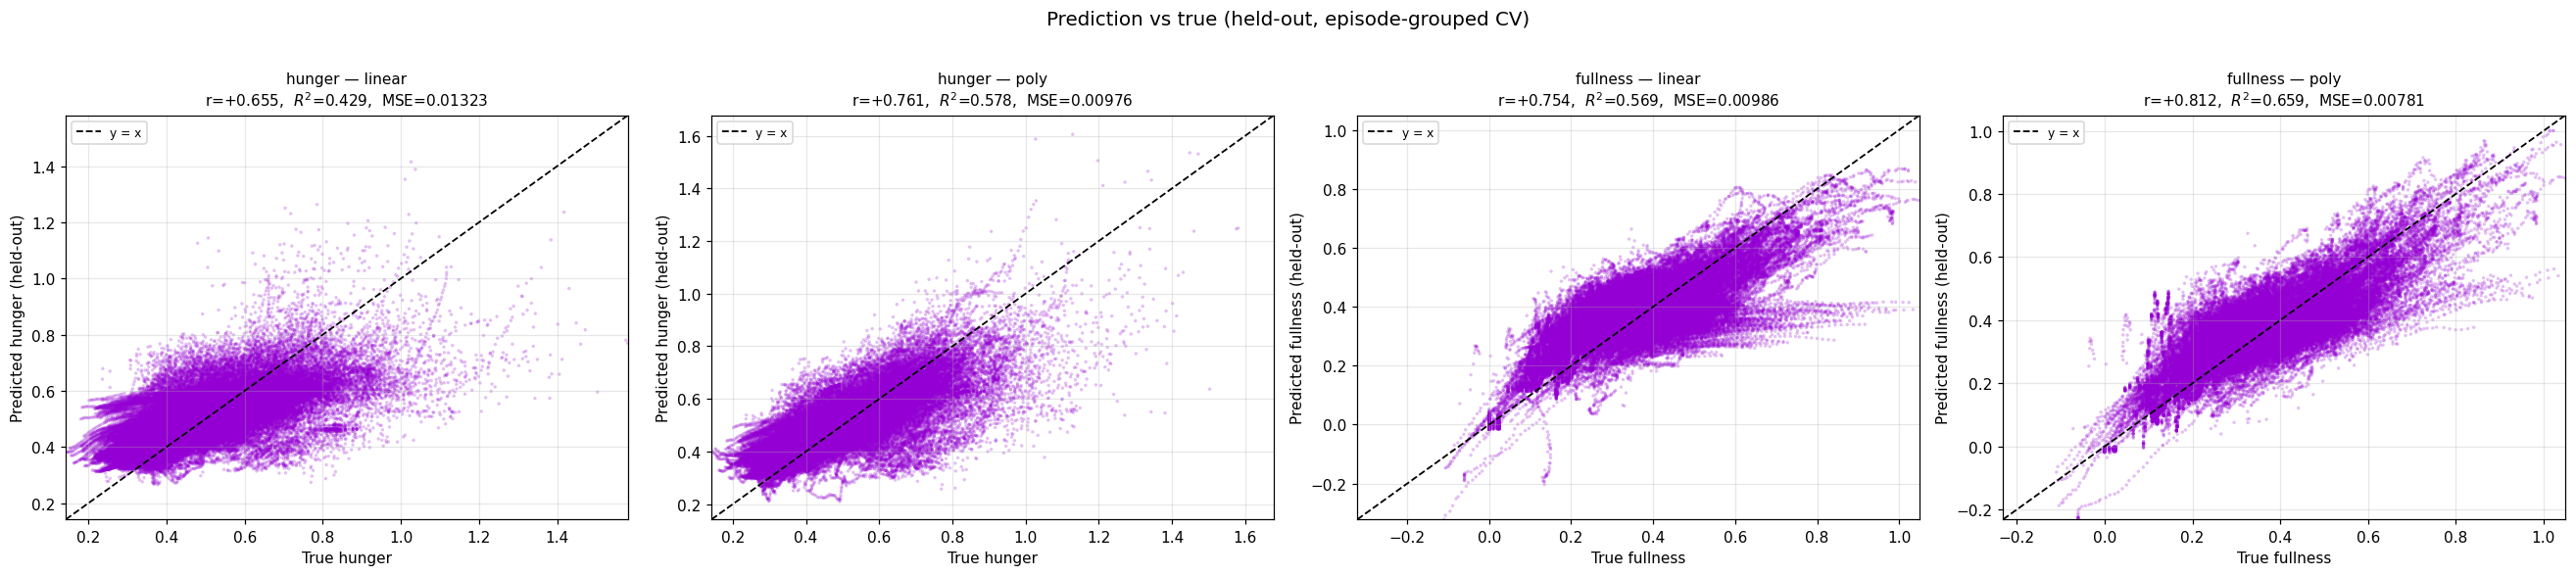


Saved results/plots_inference_normal/decode_pred_vs_true.png


In [13]:
# ── Correlation plot: predicted vs true (held-out, all pooled steps) ──────
n_col = len(DECODE_TARGETS) * len(FIT_MODES)
fig, axes = plt.subplots(1, n_col, figsize=(6 * n_col, 5.2))
if n_col == 1:
    axes = [axes]

k = 0
for tname in DECODE_TARGETS:
    y = np.asarray(targets[tname], dtype=float)
    for mode in FIT_MODES:
        f   = fits[(tname, mode)]
        ax  = axes[k]; k += 1
        ok  = ~np.isnan(f['oof'])
        yt, yp = y[ok], f['oof'][ok]

        ax.scatter(yt, yp, s=5, alpha=0.25, color='darkviolet', edgecolors='none')
        lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
        ax.plot(lims, lims, ls='--', color='black', lw=1.2, label='y = x')
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel(f'True {tname}')
        ax.set_ylabel(f'Predicted {tname} (held-out)')
        ax.set_title(f'{tname} — {mode}\n'
                     f'r={f["r_cv"]:+.3f},  $R^2$={f["r2_cv"]:.3f},  '
                     f'MSE={f["mse_cv"]:.5f}', fontsize=10)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        print(f'{tname:9s} [{mode:6s}]  MSE={f["mse_cv"]:.6f}  '
              f'R^2={f["r2_cv"]:.4f}  r={f["r_cv"]:+.4f}')

fig.suptitle('Prediction vs true (held-out, episode-grouped CV)', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, 'decode_pred_vs_true.png'), bbox_inches='tight')
plt.show()
print(f'\nSaved {PLOT_DIR}/decode_pred_vs_true.png')

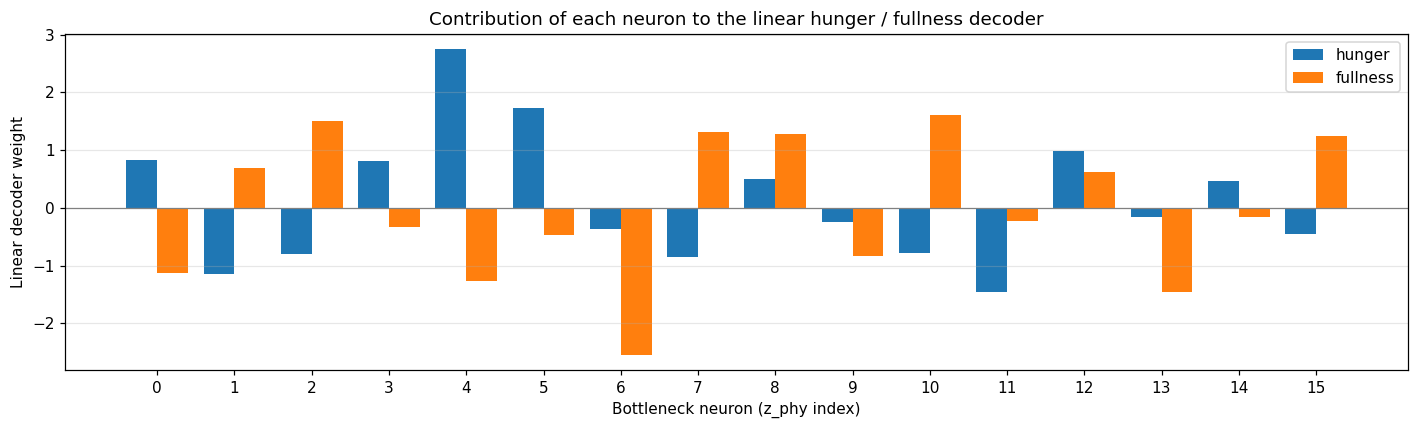

hunger   : intercept=+0.5269   top neurons by |w| -> z4(+2.746), z5(+1.725), z11(-1.454), z1(-1.140), z12(+0.982)
fullness : intercept=+1.2279   top neurons by |w| -> z6(-2.543), z10(+1.613), z2(+1.508), z13(-1.461), z7(+1.318)

Saved results/plots_inference_normal/decoder_weights.png (+ .pkl)


In [14]:
# ── Which neurons carry the signal? (linear decoder weights) ──────────────
if 'linear' in FIT_MODES:
    fig, ax = plt.subplots(figsize=(13, 4))
    for a, tname in enumerate(DECODE_TARGETS):
        coefs = fits[(tname, 'linear')]['model'].coef_.ravel()
        ax.bar(x + (a - (len(DECODE_TARGETS)-1)/2) * w, coefs, w, label=tname)
    ax.axhline(0, color='grey', lw=0.8)
    ax.set_xticks(x)
    ax.set_xlabel('Bottleneck neuron (z_phy index)')
    ax.set_ylabel('Linear decoder weight')
    ax.set_title('Contribution of each neuron to the linear hunger / fullness decoder')
    ax.legend(); ax.grid(alpha=0.3, axis='y')
    fig.tight_layout()
    fig.savefig(os.path.join(PLOT_DIR, 'decoder_weights.png'), bbox_inches='tight')
    plt.show()

    wrows = {'neuron': np.arange(z_dim)}
    for tname in DECODE_TARGETS:
        f = fits[(tname, 'linear')]
        wrows[f'w_{tname}'] = f['model'].coef_.ravel()
        print(f'{tname:9s}: intercept={f["model"].intercept_:+.4f}   '
              f'top neurons by |w| -> '
              + ', '.join(f'z{j}({f["model"].coef_.ravel()[j]:+.3f})'
                          for j in np.argsort(np.abs(f['model'].coef_.ravel()))[::-1][:5]))
    pd.DataFrame(wrows).to_pickle(os.path.join(PLOT_DIR, 'decoder_weights.pkl'))
    print(f'\nSaved {PLOT_DIR}/decoder_weights.png (+ .pkl)')
else:
    print("Skipped — 'linear' not in FIT_MODES (polynomial weights are not "
          'directly interpretable per neuron).')

### Reading section 4

**Use the held-out (`_cv`) numbers, not the in-sample ones.** A high in-sample R² with a
near-zero or negative held-out R² means the decoder is memorising the training episodes,
not recovering a real relationship — this happened badly at low `N_INFERENCE` during
testing.

The per-neuron correlation and decoder-weight plots identify *which* bottleneck units
carry the signal. Note the two targets are not independent: hunger and fullness are
driven by the same eating events, so a neuron that tracks meal timing will show up for
both, with opposite sign.

To add the non-linear comparison, set `FIT_MODES = ['linear', 'poly']` in the config
cell and re-run from section 4. If the polynomial fit's held-out R² is not clearly
better than the linear one, the relationship is adequately linear and the simpler model
should be reported.


## 5. Save all plotting data (pkl) + model metadata (json)

Persists **every** array the plots above use — the pooled capture *and* the single-run (representative-episode) slices — plus a paper-ready `model_metadata.json`, all into `PLOT_DIR`. Load any `.pkl` with `pd.read_pickle` / `pickle.load`; none of it requires re-running inference.

In [15]:
# === SAVE-ALL-PLOTTING-DATA-AND-METADATA ===
# Consolidated save step. Runs after every section so all variables exist.
import pickle
from envs.env_config import NUTRIENT_CONFIG, SHADOW_NUTRIENT_CONFIG

def _save_pkl(obj, fname):
    p = os.path.join(PLOT_DIR, fname)
    with open(p, 'wb') as fh:
        pickle.dump(obj, fh, protocol=pickle.HIGHEST_PROTOCOL)
    print(f'Saved {p}')
    return p

# raw-unit (min,max) per regulated nutrient, for de-normalising in any plot
nutrient_minmax = {nm: (float(env._nutrient_mins[nm]), float(env._nutrient_maxs[nm]))
                   for nm in names}

# ── (a) Pooled capture — backs §1b, §2, §3, §4 ─────────────────────────────
pooled_capture = {
    'z_phy':               z_phy,
    'phy_nutrients':       phy,
    'reward':              rew,
    'is_awake':            awake,
    'action_sum':          act_sum,
    'ate':                 ate,
    'episode_idx':         episode_idx,
    'calories_cumulative': meta['calories_cumulative'],
    'targets':             {k: np.asarray(v) for k, v in targets.items()},
    'nutrient_names':      list(names),
    'shadow_names':        list(env.shadow_nutrient_names),
    'target_norm':         tgt,
    'target_low':          low,
    'target_high':         high,
    'nutrient_minmax':     nutrient_minmax,
    'sleep_windows':       sleep_wins_all,
    'n_inference':         int(N_INFERENCE),
    'seed':                int(SEED_TO_LOAD),
    'checkpoint':          CKPT_NAME,
}
_save_pkl(pooled_capture, 'pooled_capture.pkl')

# ── (b) Representative (best) episode — backs the single-run plots ─────────
phy_raw_b = np.stack(
    [phy_b[:, i] * (nutrient_minmax[nm][1] - nutrient_minmax[nm][0]) + nutrient_minmax[nm][0]
     for i, nm in enumerate(names)], axis=1)

representative_episode = {
    'episode':          int(BEST_EP),
    'total_return':     float(best_ret),
    't':                t,
    'phy_norm':         phy_b,
    'phy_raw':          phy_raw_b,
    'z_phy':            z_b,
    'selected_neurons': [int(j) for j in sel],
    'is_awake':         awake_b,
    'ate':              ate_b,
    'eat_steps':        eat_steps,
    'sleep_windows':    sleep_wins,
    'nutrient_names':   list(names),
    'nutrient_minmax':  nutrient_minmax,
    'target_norm':      tgt, 'target_low': low, 'target_high': high,
    'decode': {
        f'{tname}|{mode}': {
            'true':     np.asarray(targets[tname])[mask_best],
            'pred_oof': fits[(tname, mode)]['oof'][mask_best],
            'r2_cv':    float(fits[(tname, mode)]['r2_cv']),
            'mse_cv':   float(fits[(tname, mode)]['mse_cv']),
            'r_cv':     float(fits[(tname, mode)]['r_cv']),
        }
        for tname in DECODE_TARGETS for mode in FIT_MODES
    },
}
_save_pkl(representative_episode, 'representative_episode.pkl')

# ── (c) Pooled held-out decode predictions — backs §4 pred-vs-true scatter ─
decode_predictions = {
    'episode_idx': episode_idx,
    'targets': {
        f'{tname}|{mode}': {
            'true':     np.asarray(targets[tname], dtype=float),
            'pred_oof': fits[(tname, mode)]['oof'],
        }
        for tname in DECODE_TARGETS for mode in FIT_MODES
    },
}
_save_pkl(decode_predictions, 'decode_predictions.pkl')

# ── (d) Paper-ready model metadata (JSON) ──────────────────────────────────
def _agg(col):
    return {'mean': float(stats_df[col].mean()), 'std': float(stats_df[col].std())}

model_metadata = {
    'checkpoint': {
        'meta_path':         CKPT_META,
        'name':              CKPT_NAME,
        'seed':              ckpt_meta.get('seed'),
        'shared':            bool(ckpt_meta.get('shared')),
        'hidden':            ckpt_meta.get('hidden'),
        'best_return':       ckpt_meta.get('best_return'),
        'best_episode':      ckpt_meta.get('best_episode'),
        'separate_branches': ckpt_meta.get('separate_branches'),
    },
    'bottlenecks': {name: {'dim': int(info['dim'])}
                    for name, info in agent.list_bottlenecks().items()},
    'env': {
        'food_folder':           env.food_folder,
        'num_foods':             int(env.num_foods),
        'num_items':             int(env.num_items),
        'food_items':            list(env.item_list),
        'max_steps':             int(env.max_steps),
        'awake_steps_per_cycle': int(env.awake_steps),
        'sleep_steps_per_cycle': int(env.sleep_steps),
        'cycle_length':          int(env.cycle_length),
        'minutes_per_step':      int(env.minutes_per_step),
        'is_continuous':         bool(env.is_continuous),
        'consumption_threshold': float(env.consumption_threshold),
    },
    'nutrient_config':        {nm: dict(cfg) for nm, cfg in NUTRIENT_CONFIG.items()},
    'shadow_nutrient_config': {nm: dict(cfg) for nm, cfg in SHADOW_NUTRIENT_CONFIG.items()},
    'run': {
        'n_inference':            int(N_INFERENCE),
        'deterministic':          bool(DETERMINISTIC),
        'reward_threshold':       float(REWARD_THRESHOLD),
        'representative_episode': int(BEST_EP),
        'representative_return':  float(best_ret),
    },
    'results': {
        'avg_reward':     _agg('avg_reward'),
        'avg_distance':   _agg('avg_distance'),
        'avg_signed_err': _agg('avg_signed_err'),
        'food_items':     _agg('food_items'),
        'total_return':   _agg('total_reward'),
        'per_nutrient_signed_err_mean':
            {nm: float(stats_df[f'signed_err_{nm}'].mean()) for nm in names},
        'decode': {
            f'{r["target"]}|{r["fit"]}': {
                'r2_cv': float(r['r2_cv']), 'mse_cv': float(r['mse_cv']),
                'r_cv': float(r['r_cv']),
                'r2_in': float(r['r2_in']), 'mse_in': float(r['mse_in']),
            } for _, r in decode_df.iterrows()
        },
    },
}
_meta_path = os.path.join(PLOT_DIR, 'model_metadata.json')
with open(_meta_path, 'w') as fh:
    json.dump(model_metadata, fh, indent=2)
print(f'Saved {_meta_path}')
print(f'\nAll plotting data + metadata written to {PLOT_DIR}')


Saved results/plots_inference_normal/pooled_capture.pkl
Saved results/plots_inference_normal/representative_episode.pkl
Saved results/plots_inference_normal/decode_predictions.pkl
Saved results/plots_inference_normal/model_metadata.json

All plotting data + metadata written to results/plots_inference_normal
